Project 2 Jupyter Notebook
========

### Group: James Lind
Authors: Ivan Chan, Isha Chhabra, Matthew Arcaina, Kira Obsitnik, Zixu Yang

In this notebook, we'll solve the minimum cost diet problem using a set of procedures discussed in previous lectures. 

The food prices dataset we constructed is based on Berkeley's Whole Foods Store Data. We selected roughly 180 food items, with the majority of them being vegan. We also utilized the class's Dietary Requirements spreadsheet for our dietary requirements, as our targeted population is Vegan UC Berkeley Students. Then we will map our foods to their corresponding nutritional information from the USDA fooddatacentral API.

### Set up & Imports
Below are all necessary imports and pip installs for the rest of this project. 

**Please ensure all neccessary files are in the folder before running the below pip install.**

In [3]:
%pip install -r requirements.txt --upgrade

  Using cached pint-0.25.2-py3-none-any.whl.metadata (10 kB)
  Using cached numpy-2.4.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.1-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached scipy-1.17.1-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached gspread-6.2.1-py3-none-any.whl.metadata (11 kB)
  Using cached gspread_pandas-3.3.0-py2.py3-none-any.whl.metadata (10 kB)
  Using cached bottleneck-1.6.0-cp311-cp311-manylinux1_x86_64.manylinux_2_28_x86_64.manylinux_2_5_x86_64.whl.metadata (8.2 kB)
  Using cached eep153_tools-0.12.4-py2.py3-none-any.whl.metadata (363 bytes)
  Using cached fooddatacentral-1.0.12-py3-none-any.whl.metadata (2.1 kB)
  Using cached python_gnupg-0.5.6-py2.py3-none-any.whl.metadata (2.1 kB)
  Using cached flexcache-0.3-py3-none-any.whl.metadata (7.0 kB)
  Using

In [4]:
apikey = "NMhO744t7FjAKAlWrA1RCM6jVO07YE3kRTg1TlPo"  
# You could replace it with your key!

In [5]:
import fooddatacentral as fdc
import pandas as pd
from eep153_tools.sheets import read_sheets
import warnings
from  scipy.optimize import linprog as lp
import numpy as np
pd.options.plotting.backend = 'plotly'

## Recap for the Problem
Below are explanation in matrix algebra of our problem, this is adopt from previous lectures.

We&rsquo;re thinking about the problem of finding the cheapest possible
nutritious diet.  Last time we argued that this problem could be
expressed as a *linear program*
$$
    \min_x p'x
$$

such that
$$\begin{bmatrix}
      A\\
      -A
   \end{bmatrix}x \geq \begin{bmatrix}
                        b_{min}\\
                        -b_{max}
                      \end{bmatrix},$$

where $p$ is a vector of prices, $A$ is a matrix that maps
vectors of quantities of food into vectors of nutrients, and where
$b_{min}$ and $b_{max}$ are respectively dietary minimums
and maximums of different nutrients.  As above, we will sometimes stack these
objects, obtaining
$$
      \tilde{A} = \begin{bmatrix}
                        A_{min}\\
                        -A_{max}
                      \end{bmatrix}
  $$
and
$$
      \tilde{b} = \begin{bmatrix}
                        b_{min}\\
                        -b_{max}
                      \end{bmatrix}
  $$

In this notebook: We will the objects required by the linear
program $(p,\tilde{A},\tilde{b})$, then have the computer solve the problem for us.



## Descripition of Population of Interest, <span style="color: red;">*Deliverable [A] Descripition of Population of Interest* <a name="population-f"></span></a>

For our population of interest, we chose **UC Berkeley Undergraduate Students who consume a Vegan Diet**. 

We will explore how UC Berkeley Undergraduate students can meet daily nutritional requirements while minimizing costs through a vegan diet sourced from the **Berkeley Whole Foods**. While Whole Foods is often associated with premium pricing, it remains a primary grocery option for students living off campus. By combining local food price data with vegan-specific nutritional profiles, this project examines the feasibility of maintaining a nutritionally vegan diet at the lowest possible price point within a high-cost retail environment.

The goal of this project is to investigate the tradeoff between **affordability and vegan nutrition** for UC Berkeley Undergraduate students. Collecting a dataset of vegan food items, we aim to identify the lowest-cost combination of foods that satisfies all recommended daily nutrient requirements. Beyond finding a minimum-cost diet, the project seeks to understand how **price fluctuations in fresh produce**, such as bananas and seasonal greens, affect the overall cost and selection of meals for students maintaining a nutritionally adequate vegan lifestyle.

## Food Prices Spreadsheet, <span style="color: red;">*Deliverable [A] Data on prices for different foods* <a name="population-f"></span></a>

The code below allows us to collect data on different kinds of food with their prices from google spreadsheets. 

We have recorded the selected food items in a Google Spreadsheet: [https://docs.google.com/spreadsheets/d/18gdMQzetIll41oNgJtt3VgBpHgVn3zx57Agp89P28co/edit?usp=sharing](https://docs.google.com/spreadsheets/d/18gdMQzetIll41oNgJtt3VgBpHgVn3zx57Agp89P28co/)

In [6]:
#https://docs.google.com/spreadsheets/d/18gdMQzetIll41oNgJtt3VgBpHgVn3zx57Agp89P28co/edit?usp=sharing
df = read_sheets("18gdMQzetIll41oNgJtt3VgBpHgVn3zx57Agp89P28co",sheet='Whole Foods')

df = df.set_index('Food')

df

,Brand,Quantity,Units,Price,FDC
Food,,,,,
Strawberries,Fresh Produce,1.0,lbs,4.99,2346409
Natures Reward Cilantro,Tanimura & Antle,3.0,oz,1.59,2709782
Blueberries,Fresh Produce,1.0,pint,5.29,2346411
Lime Regular Conventional,Fresh Produce,1.0,lbs,1.18,2709170
Red Raspberries,Fresh Produce,6.0,oz,3.99,2346410
...,...,...,...,...,...
Frozen Chicken Nuggets Plant Based,IMPOSSIBLE FOODS,13.5,oz,10.99,2664241
Beyond Meat Stack Burger Plant-Based Patties,BEYOND MEAT,20.0,oz,16.99,2367272
Beyond Meat Beyond Sausage Plant-Based Dinner Sausage Links Brat Original,BEYOND MEAT,14.0,oz,7.87,2156900


### Converting Units

Below we will convert all food in either hundreds of grams (hectograms) or hundreds of milliliters (deciliters). This is for later application in FDC database in relation with nutrition information. 

**Code is adpoted from lecture notebook.**

In [7]:
# Convert food quantities to FDC units
df['FDC Quantity'] = df[['Quantity','Units']].T.apply(lambda x : fdc.units(x['Quantity'],x['Units']))

# Now divide price by the FDC Quantity to get, e.g., price per hectoliter
df['FDC Price'] = df['Price']/df['FDC Quantity']

df.dropna(how='any') # Drop food with any missing data

# To use minimum price observed
Prices = df.groupby('Food')['FDC Price'].min()

Prices

Food
365 by Whole Foods Market Chickenless Nuggets               2.062992320081521 / hectogram
365 by Whole Foods Market Grated Parmesan                  2.8148621635765165 / hectogram
365 by Whole Foods Market Non Dairy Gouda Cheese Slices    1.9797511144202005 / hectogram
365 by Whole Foods Market Organic Peeled Garlic            2.9336178354734375 / hectogram
365 by Whole Foods Market Organic Trimmed Green Beans      1.1728592348235487 / hectogram
                                                                        ...              
Wonderful Pistachios In-Shell Unsalted Nuts                2.2024179992269266 / hectogram
Wonderful Pistachios No Shells, Lightly Salted Nuts          4.40630574686842 / hectogram
Wonderful Pistachios No Shells, Roasted & Salted Nuts        4.40630574686842 / hectogram
Yellow Nectarine                                           0.8796444261176615 / hectogram
Yogurt Coconut Chocolate Mousse Organic                    4.4338637267791645 / deciliter
Name:

## Foods Nutrition Information, <span style="color: red;">*Deliverable [A] Nutritional Content on different foods* <a name="population-f"></span></a>

In this delieverable, we will build the matrix $A$, which maps quantities of food into nutrients. Here we will do lookups on USDA database to get their nutritional information. 

**This code would need to run for roughly 1-2 minutes for the first time. Code is adopted from lecture notebooks.**

In [8]:
D = {}
count = 0
for food in df.index:
    try:
        fdc_id = str(int(df.loc[df.index==food,:].FDC.values[0]))
        count+=1
        D[food] = fdc.nutrients(apikey, fdc_id).Quantity
    except AttributeError:
        warnings.warn(f"Couldn't find FDC Code {fdc_id} for food {food}.")

D = pd.DataFrame(D,dtype=float)

D

,Strawberries,Natures Reward Cilantro,Blueberries,Lime Regular Conventional,Red Raspberries,PRODUCE Organic Mandarin Bag,Blackberries,Organic Rancher Organic Ground Beef 93% Lean/7% Fat,Organic Baby Spinach,Banana Conventional,...,Tofurky Original Deli Slices,Dr. Praeger's Perfect Burgers,Peppers Red Fire Roasted Organic,Frozen Burger Veggie Mushroom Mozzarella,Field Roast Signature Stadium Plant-Based Hot Dogs,Frozen Chicken Nuggets Plant Based,Beyond Meat Stack Burger Plant-Based Patties,Beyond Meat Beyond Sausage Plant-Based Dinner Sausage Links Brat Original,Louisville Vegan Jerky Sweet & Smoky Carolina Mustard BBQ Vegan Meat,"Dr. Praeger's, Mushroom Risotto Veggie Burgers"
5-methyl tetrahydrofolate (5-MTHF),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alanine,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.307,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"Alcohol, ethyl",NaN,0.0,NaN,0.00,NaN,NaN,NaN,0.000,NaN,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amino acids,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Arginine,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.358,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Vitamins and Other Components,0.000,NaN,0.00000,NaN,0.0000,0.00000,0.0000,0.000,0.0000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Water,90.830,92.2,84.19000,88.30,85.5500,84.65000,86.4500,71.720,92.5200,75.60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zeaxanthin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,191.3000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"Zinc, Zn",0.114,0.5,0.08534,0.11,0.2213,0.06869,0.1889,4.970,0.4471,0.16,...,NaN,NaN,NaN,NaN,NaN,3.95,4.07,NaN,NaN,NaN


### Dietary Requirement

Now we will utilized the exisiting nutrional requirements spreadsheet provided in previous lectures to construct the vectors
$b_{min}$ and $b_{max}$.

The original data for nutritional requirements is based on  US government recommendations available at   
[https://www.dietaryguidelines.gov/sites/default/files/2021-03/Dietary_Guidelines_for_Americans-2020-2025.pdf](https://www.dietaryguidelines.gov/sites/default/files/2021-03/Dietary_Guidelines_for_Americans-2020-2025.pdf)

We will use the Google Spreadsheet:
[https://docs.google.com/spreadsheets/d/1y95IsQ4HKspPW3HHDtH7QMtlDA66IUsCHJLutVL-MMc/](https://docs.google.com/spreadsheets/d/1y95IsQ4HKspPW3HHDtH7QMtlDA66IUsCHJLutVL-MMc/).     
**Note that there are tweaks in the nutrient labels to match those in the FDC data.**

We've broken down the requirements into three different tables. The first is *minimum* quantities that we need to  satisfy.  For example, this table tells us that a 20 year-old female needs at least 46 grams of protein per day.

**Code is adopted from lecture notebooks.**

In [9]:
RDIs = read_sheets('https://docs.google.com/spreadsheets/d/1y95IsQ4HKspPW3HHDtH7QMtlDA66IUsCHJLutVL-MMc/')

bmin = RDIs['diet_minimums'].set_index('Nutrition')
bmax = RDIs['diet_maximums'].set_index('Nutrition')

# Drop string describing source
bmin = bmin.drop('Source',axis=1)
bmax = bmax.drop('Source',axis=1)

bmin

,C 1-3,F 4-8,M 4-8,F 9-13,M 9-13,F 14-18,M 14-18,F 19-30,M 19-30,F 31-50,M 31-50,F 51+,M 51+
Nutrition,,,,,,,,,,,,,
Energy,1000.0,1200.0,1400.0,1600.0,1800.0,1800.0,2200.0,2000.0,2400.0,1800.0,2200.0,1600.0,2000.0
Protein,13.0,19.0,19.0,34.0,34.0,46.0,52.0,46.0,56.0,46.0,56.0,46.0,56.0
"Fiber, total dietary",14.0,16.8,19.6,22.4,25.2,25.2,30.8,28.0,33.6,25.2,30.8,22.4,28.0
"Folate, DFE",150.0,200.0,200.0,300.0,300.0,400.0,400.0,400.0,400.0,400.0,400.0,400.0,400.0
"Calcium, Ca",700.0,1000.0,1000.0,1300.0,1300.0,1300.0,1300.0,1000.0,1000.0,1000.0,1000.0,1200.0,1000.0
"Carbohydrate, by difference",130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0
"Iron, Fe",7.0,10.0,10.0,8.0,8.0,15.0,11.0,18.0,8.0,18.0,8.0,8.0,8.0
"Magnesium, Mg",80.0,130.0,130.0,240.0,240.0,360.0,410.0,310.0,400.0,320.0,420.0,320.0,420.0
Niacin,6.0,8.0,8.0,12.0,12.0,14.0,16.0,14.0,16.0,14.0,16.0,14.0,16.0


In [10]:
bmax

,C 1-3,F 4-8,M 4-8,F 9-13,M 9-13,F 14-18,M 14-18,F 19-30,M 19-30,F 31-50,M 31-50,F 51+,M 51+
Nutrition,,,,,,,,,,,,,
"Sodium, Na",1500,1900,1900,2200,2200,2300,2300,2300,2300,2300,2300,2300,2300
Energy,2500,2500,2500,2800,3000,3100,3100,3100,3100,3100,3100,3100,3100


## Solving the Problem, <span style="color: red;">*Deliverable [A] Solution* <a name="population-f"></span></a>

Here we put them together in the form of a linear program we can solve.
Recall that the mathematical problem we&rsquo;re trying to solve is
$$
    \min_x p'x
$$
such that
$$
     \tilde{A}x \geq \tilde{b}
$$



### Objective function ($p$)
Here we will compute a vector of prices based on our converted units aboved, this gives us a vector of prices where quantities are all in 100 g or ml units.

**Code is adopted from lecture notebooks.**

In [11]:
p = Prices.apply(lambda x:x.magnitude).dropna()

# Compile list that we have both prices and nutritional info for; drop if either missing
use = p.index.intersection(D.columns)
p = p[use]

p

365 by Whole Foods Market Chickenless Nuggets              2.062992
365 by Whole Foods Market Grated Parmesan                  2.814862
365 by Whole Foods Market Non Dairy Gouda Cheese Slices    1.979751
365 by Whole Foods Market Organic Peeled Garlic            2.933618
365 by Whole Foods Market Organic Trimmed Green Beans      1.172859
                                                             ...   
Wonderful Pistachios In-Shell Unsalted Nuts                2.202418
Wonderful Pistachios No Shells, Lightly Salted Nuts        4.406306
Wonderful Pistachios No Shells, Roasted & Salted Nuts      4.406306
Yellow Nectarine                                           0.879644
Yogurt Coconut Chocolate Mousse Organic                    4.433864
Name: FDC Price, Length: 182, dtype: float64

### Nutrient Mapping Matrix ($A$)
The matrix $A$ maps a bag of groceries $x$ into nutrients, but we don't need to keep track of nutrients for which we don't have contraints.

**Code is adopted from lecture notebooks.**

In [12]:
# Drop nutritional information for foods we don't know the price of,
# and replace missing nutrients with zeros.
Aall = D[p.index].fillna(0)

# Drop rows of A that we don't have constraints for.
Amin = Aall.loc[bmin.index]

Amax = Aall.loc[bmax.index]

# Maximum requirements involve multiplying constraint by -1 to make <=.
A = pd.concat([Amin,-Amax])

A

,365 by Whole Foods Market Chickenless Nuggets,365 by Whole Foods Market Grated Parmesan,365 by Whole Foods Market Non Dairy Gouda Cheese Slices,365 by Whole Foods Market Organic Peeled Garlic,365 by Whole Foods Market Organic Trimmed Green Beans,4% Cottage Cheese,"Abbot’s, Plant-Based ChorizoVegan Gluten-Free",AeroFarms Micro Rainbow Mix,Almond Breeze Blue Diamond Almond milk,BARD VALLEY Organic Pitted Fresh Medjool Dates,...,Wildwood Organic Sproutofu Extra Firm,"Wildwood, Sprout Firm Tofu",Wonderful Pistachio Lightly Salted Shelled Pistachios,Wonderful Pistachio Roasted & Salted Shelled Pistachios,"Wonderful Pistachios In Shell, Lightly Salted Nuts",Wonderful Pistachios In-Shell Unsalted Nuts,"Wonderful Pistachios No Shells, Lightly Salted Nuts","Wonderful Pistachios No Shells, Roasted & Salted Nuts",Yellow Nectarine,Yogurt Coconut Chocolate Mousse Organic
Nutrition,,,,,,,,,,,,,,,,,,,,,
Energy,217.0,0.00000,357.00,100.0,29.00,100.00,165.00,18.00,25.00,304.00,...,94.00,94.00,571.000,571.000,571.000,571.000,571.000,325.000,43.00,280.0
Protein,15.0,30.13912,25.00,0.0,1.18,11.33,17.65,3.57,0.42,2.17,...,9.41,9.41,21.430,21.430,21.430,21.430,21.430,21.430,0.71,0.0
"Fiber, total dietary",3.3,0.00000,0.00,0.0,3.50,0.00,2.40,0.00,0.40,8.70,...,1.20,1.20,10.700,10.700,10.700,10.700,10.700,10.700,1.40,4.0
"Folate, DFE",0.0,0.00000,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.0
"Calcium, Ca",33.0,950.40000,714.00,200.0,47.00,67.00,35.00,0.00,188.00,65.00,...,118.00,118.00,107.000,107.000,107.000,107.000,107.000,107.000,0.00,0.0
"Carbohydrate, by difference",20.0,4.33188,3.57,20.0,5.88,4.67,7.06,0.00,3.33,71.74,...,1.18,1.18,28.570,28.570,28.570,28.570,28.570,28.570,10.71,16.0
"Iron, Fe",1.8,0.14050,0.00,0.0,0.42,0.24,3.18,0.00,0.29,0.00,...,1.69,1.69,3.930,3.930,3.930,3.930,3.930,3.930,0.26,0.0
"Magnesium, Mg",0.0,35.37000,0.00,0.0,0.00,0.00,0.00,0.00,6.00,0.00,...,0.00,0.00,107.000,107.000,107.000,107.000,107.000,107.000,0.00,0.0
Niacin,0.0,0.14060,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.0


### Constraint vector ($b$)

This step we will compute the right hand side vector $b$ in the expression
$$
    Ax\geq b
$$

**Code is adopted from lecture notebooks.**

In [13]:
b = pd.concat([bmin,-bmax]) # Note sign change for max constraints

b

,C 1-3,F 4-8,M 4-8,F 9-13,M 9-13,F 14-18,M 14-18,F 19-30,M 19-30,F 31-50,M 31-50,F 51+,M 51+
Nutrition,,,,,,,,,,,,,
Energy,1000.0,1200.0,1400.0,1600.0,1800.0,1800.0,2200.0,2000.0,2400.0,1800.0,2200.0,1600.0,2000.0
Protein,13.0,19.0,19.0,34.0,34.0,46.0,52.0,46.0,56.0,46.0,56.0,46.0,56.0
"Fiber, total dietary",14.0,16.8,19.6,22.4,25.2,25.2,30.8,28.0,33.6,25.2,30.8,22.4,28.0
"Folate, DFE",150.0,200.0,200.0,300.0,300.0,400.0,400.0,400.0,400.0,400.0,400.0,400.0,400.0
"Calcium, Ca",700.0,1000.0,1000.0,1300.0,1300.0,1300.0,1300.0,1000.0,1000.0,1000.0,1000.0,1200.0,1000.0
"Carbohydrate, by difference",130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0
"Iron, Fe",7.0,10.0,10.0,8.0,8.0,15.0,11.0,18.0,8.0,18.0,8.0,8.0,8.0
"Magnesium, Mg",80.0,130.0,130.0,240.0,240.0,360.0,410.0,310.0,400.0,320.0,420.0,320.0,420.0
Niacin,6.0,8.0,8.0,12.0,12.0,14.0,16.0,14.0,16.0,14.0,16.0,14.0,16.0


### Solving the problem

We will finally solve for the problem.

**Code is adopted from lecture notebooks.**

In [14]:
tol = 1e-6 # Numbers in solution smaller than this (in absolute value) treated as zeros

## Choose sex/age group!
group = "F 19-30"

# Now solve problem!  (Note that the linear program solver we'll use assumes
# "less-than-or-equal" constraints.  We can switch back and forth by
# multiplying $A$ and $b$ by $-1$.)

result = lp(p, -A, -b[group], method='highs')

result

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: 10.316456941064242
              x: [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            nit: 13
          lower:  residual: [ 0.000e+00  0.000e+00 ...  0.000e+00
                              0.000e+00]
                 marginals: [ 2.077e+00  1.575e-01 ...  8.997e-01
                              4.767e+00]
          upper:  residual: [       inf        inf ...        inf
                                    inf]
                 marginals: [ 0.000e+00  0.000e+00 ...  0.000e+00
                              0.000e+00]
          eqlin:  residual: []
                 marginals: []
        ineqlin:  residual: [ 1.100e+03  3.058e+01 ...  1.820e+03
                              0.000e+00]
                 marginals: [-0.000e+00 -0.000e+00 ... -0.000e+00
                             -1.191e-03]
 mip_node_count: 0
 mip_dual_bound: 0.0
        mip

### Interpretation

Let's interprete the results.

**Code is adopted from lecture notebooks.**

In [15]:
print(f"Cost of diet for {group} is ${result.fun:.2f} per day.")

Cost of diet for F 19-30 is $10.32 per day.


In [16]:
# Put back into nice series
diet = pd.Series(result.x,index=p.index)

print("\nYou'll be eating (in 100s of grams or milliliters):")
print(diet[diet >= tol])  # Drop items with quantities less than the precision of calculation.


You'll be eating (in 100s of grams or milliliters):
BLUE DIAMOND Unsweetened Vanilla Almondmilk     1.379621
Banana Conventional                            19.280923
Califia Farms - Toasted Coconut Almond Milk     0.391124
Elbows                                          0.836431
Impossible, Burger Patties Grilled              0.605665
Natures Reward Cilantro                         1.786873
Oatly Full Fat Oat Milk                         1.172280
Organic Black Beans                             1.317826
dtype: float64


Given this diet, what are nutritional outcomes?

In [17]:
tab = pd.DataFrame({"Outcome":np.abs(A).dot(diet),"Recommendation":np.abs(b[group])})
print("\nWith the following nutritional outcomes of interest:")
tab


With the following nutritional outcomes of interest:


,Outcome,Recommendation
Nutrition,,
Energy,3100.000000,2000.0
Protein,76.581216,46.0
"Fiber, total dietary",70.078843,28.0
"Folate, DFE",400.000000,400.0
"Calcium, Ca",1000.000000,1000.0
"Carbohydrate, by difference",611.352743,130.0
"Iron, Fe",18.000000,18.0
"Magnesium, Mg",700.803096,310.0
Niacin,26.980058,14.0


Finally, what are the constraints that bind?  Finding a less expensive diet might involve finding less expensive sources for these particular nutrients.

In [18]:
print("\nConstraining nutrients are:")
excess = tab.diff(axis=1).iloc[:,1]
print(excess.loc[np.abs(excess) < tol].index.tolist())


Constraining nutrients are:
['Folate, DFE', 'Calcium, Ca', 'Iron, Fe', 'Riboflavin', 'Vitamin A, RAE', 'Vitamin E (alpha-tocopherol)', 'Zinc, Zn', 'Energy']


### Extension
In this extension, we will run through all age groups post M/F 14-18 because the student population in Berkeley are varied from 17 or above.

In [19]:
target_groups = ["F 14-18", "M 14-18", "F 19-30", "M 19-30", "F 31-50", "M 31-50", "F 51+", "M 51+"]
summary_costs = {}

for each in target_groups:
    result = lp(p, -A, -b[each], method='highs')
    diet = pd.Series(result.x,index=p.index)
    summary_costs[each] = result.fun
    
    print("\n" + "="*50)
    print(f"RESULTS FOR GROUP: {each}")

    print(f"Cost of diet for {each} is ${result.fun:.2f} per day.")
    print("\nYou'll be eating (in 100s of grams or milliliters):")
    print(diet[diet >= tol])


RESULTS FOR GROUP: F 14-18
Cost of diet for F 14-18 is $10.95 per day.

You'll be eating (in 100s of grams or milliliters):
365 by Whole Foods Market Grated Parmesan       0.650154
Banana Conventional                            20.534449
Califia Farms - Toasted Coconut Almond Milk     0.419889
Impossible, Burger Patties Grilled              0.153697
Natures Reward Cilantro                         1.483601
Oatly Full Fat Oat Milk                         2.678985
Organic Black Beans                             1.520257
Organic Roasted Unsalted Sunflower Kernals      0.177576
dtype: float64

RESULTS FOR GROUP: M 14-18
Cost of diet for M 14-18 is $11.44 per day.

You'll be eating (in 100s of grams or milliliters):
365 by Whole Foods Market Grated Parmesan       0.354795
Banana Conventional                            19.532976
Califia Farms - Toasted Coconut Almond Milk     0.396908
Impossible, Burger Patties Grilled              0.120477
Natures Reward Cilantro                         1.7

In [20]:
# Cleaner Look for minimum prices for each group
cost_df = pd.Series(summary_costs)
print("\nFinal Cost Comparison")
print(cost_df)


Final Cost Comparison
F 14-18    10.949989
M 14-18    11.435272
F 19-30    10.316457
M 19-30    10.791718
F 31-50    10.316457
M 31-50    10.791718
F 51+       9.402258
M 51+      10.791718
dtype: float64


Looking at the results and the list of foods, we noticed that **Bananas** are the ones that require heavy consumption in each age group. This is likely due to the low price of Banana compared to the relative food prices in Whole Foods.

## Sensitivity of Solution, <span style="color: red;">*Deliverable [C] Sensitivity of Solution* <a name="population-f"></span></a>

In this section, we will further focus on our minimum-cost diet solution and discover how sensitive it is to changes in food prices. In particular, we would also look at how the prices of **Bananas** might have an effect on the solution.

First, we will utilize the function `solve_subsistence_problem` in `diet_problem2` notebook, which computes the solution with all the steps we did above. 

**Code is adopted from lecture notebooks.**

In [21]:
def solve_subsistence_problem(FoodNutrients, Prices, dietmin, dietmax, max_weight=None, tol=1e-6):
    """
    Inputs:
       - FoodNutrients : A pd.DataFrame with rows corresponding to foods, columns to nutrients.
       - Prices : A pd.Series of prices for different foods
       - diet_min : A pd.Series of DRIs, with index corresponding to columns of FoodNutrients,
                    describing minimum intakes.
       - diet_max : A pd.Series of DRIs, with index corresponding to columns of FoodNutrients,
                    describing maximum intakes.
       - max_weight : Maximum weight (in hectograms) allowed for diet.
       - tol : Solution values smaller than this in absolute value treated as zeros.
       
    """
    p = Prices.apply(lambda x:x.magnitude).dropna()
    
    # Compile list that we have both prices and nutritional info for; drop if either missing
    use = p.index.intersection(FoodNutrients.columns)
    p = p[use]

    # Drop nutritional information for foods we don't know the price of,
    # and replace missing nutrients with zeros.
    Aall = FoodNutrients[p.index].fillna(0)

    # Drop rows of A that we don't have constraints for.
    Amin = Aall.loc[Aall.index.intersection(dietmin.index)]
    Amin = Amin.reindex(dietmin.index,axis=0)
    idx = Amin.index.to_frame()
    idx['type'] = 'min'
    #Amin.index = pd.MultiIndex.from_frame(idx)
    #dietmin.index = Amin.index
    
    Amax = Aall.loc[Aall.index.intersection(dietmax.index)]
    Amax = Amax.reindex(dietmax.index,axis=0)
    idx = Amax.index.to_frame()
    idx['type'] = 'max'
    #Amax.index = pd.MultiIndex.from_frame(idx)
    #dietmax.index = Amax.index

    # Minimum requirements involve multiplying constraint by -1 to make <=.
    A = pd.concat([Amin, -Amax])

    b = pd.concat([dietmin, -dietmax]) # Note sign change for max constraints

    # Make sure order of p, A, b are consistent
    A = A.reindex(p.index,axis=1)
    A = A.reindex(b.index,axis=0)

    if max_weight is not None:
        # Add up weights of foods consumed
        A.loc['Hectograms'] = -1
        b.loc['Hectograms'] = -max_weight
        
    # Now solve problem!  (Note that the linear program solver we'll use assumes
    # "less-than-or-equal" constraints.  We can switch back and forth by
    # multiplying $A$ and $b$ by $-1$.)

    result = lp(p, -A, -b, method='highs')

    result.A = A
    result.b = b
    
    if result.success:
        result.diet = pd.Series(result.x,index=p.index)
    else: # No feasible solution?
        warnings.warn(result.message)
        result.diet = pd.Series(result.x,index=p.index)*np.nan  

    return result

For simplicity, we would look at the sensitivity for `M 19-30`. 
                                                 
Below is a sanity check to see if the solution is consistent to the one above.

In [22]:
group = 'M 19-30'
tol = 1e-6
FoodNutrients = pd.DataFrame(D,dtype=float)
Prices = df.groupby('Food',sort=False)['FDC Price'].min()
diet_min = bmin
diet_max = bmax

result = solve_subsistence_problem(FoodNutrients,Prices,diet_min[group],diet_max[group],tol=tol)

print("Cost of diet for %s is $%4.2f per day.\n" % (group,result.fun))

# Put back into nice series
diet = result.diet

print("\nDiet (in 100s of grams or milliliters):")
print(diet[diet >= tol])  # Drop items with quantities less than precision of calculation.
print()

tab = pd.DataFrame({"Outcome":np.abs(result.A).dot(diet),"Recommendation":np.abs(result.b)})
print("\nWith the following nutritional outcomes of interest:")
print(tab)
print()

print("\nConstraining nutrients are:")
excess = tab.diff(axis=1).iloc[:,1]
print(excess.loc[np.abs(excess) < tol*100].index.tolist())

Cost of diet for M 19-30 is $10.79 per day.


Diet (in 100s of grams or milliliters):
Natures Reward Cilantro                         1.861774
Banana Conventional                            18.971336
365 by Whole Foods Market Grated Parmesan       0.010036
Organic Roasted Salted Sunflower Kernels        0.126548
Organic Roasted Unsalted Sunflower Kernals      1.044391
Elbows                                          0.049903
Oatly Full Fat Oat Milk                         3.785238
Califia Farms - Toasted Coconut Almond Milk     0.384020
Impossible, Burger Patties Grilled              0.111807
dtype: float64


With the following nutritional outcomes of interest:
                                    Outcome  Recommendation
Nutrition                                                  
Energy                          3100.000000          2400.0
Protein                           56.000000            56.0
Fiber, total dietary              57.071017            33.6
Folate, DFE                    

### Effects of Price Changes on Subsistence Diet

#### Case 1: General Price Changes
As prices change, we should expect the minimum cost diet to also change. The code below creates a graph that changes prices away from the `base’ case one food at a time, and plots changes in total diet cost.

**Code would take about a minute to compute. Code is adopted from lecture notebooks.**

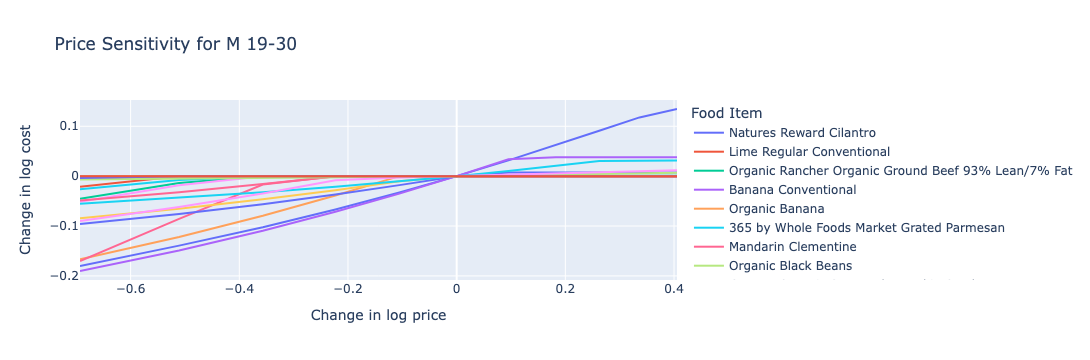

In [23]:
scale = [.5,.6,.7,.8,.9,1.,1.1,1.2,1.3,1.4,1.5]

cost0 = solve_subsistence_problem(FoodNutrients,Prices,diet_min[group],diet_max[group],tol=tol).fun

Price_response={}
for s in scale:
    cost = {}
    for i,p in enumerate(Prices):
        my_p = Prices.copy()
        my_p.iloc[i] = p*s
        result = solve_subsistence_problem(FoodNutrients,my_p,diet_min[group],diet_max[group],tol=tol)
        cost[Prices.index[i]] = np.log(result.fun/cost0)
    Price_response[np.log(s)] = cost

Price_response = pd.DataFrame(Price_response).T
# This would not be ideal since we have ~180 Food Items
#Price_response.plot(labels=dict(index='change in log price',value='change in log cost'))

# This would only show the Food Items that featured in the solution
is_changing = (Price_response.abs().max() > 0)
filtered_response = Price_response.loc[:, is_changing]
filtered_response.plot(
    labels=dict(index='Change in log price', value='Change in log cost', variable='Food Item'),
    title=f"Price Sensitivity for {group}"
)

#### Case 2: Price Change in **Bananas** on Subsistence Diet
Rather than looking at the general price change, we would like to look at how the price of **Bananas** changes on the subsistence diet cost, as it is the cheapest item in Whole Foods; hence, the solution features high consumption of Bananas. Although this is a price change in one food, there are actually two Bananas in the FoodPrices spreadsheet.

**Code could take about a minute to compute. Code is adopted from lecture notebooks.**

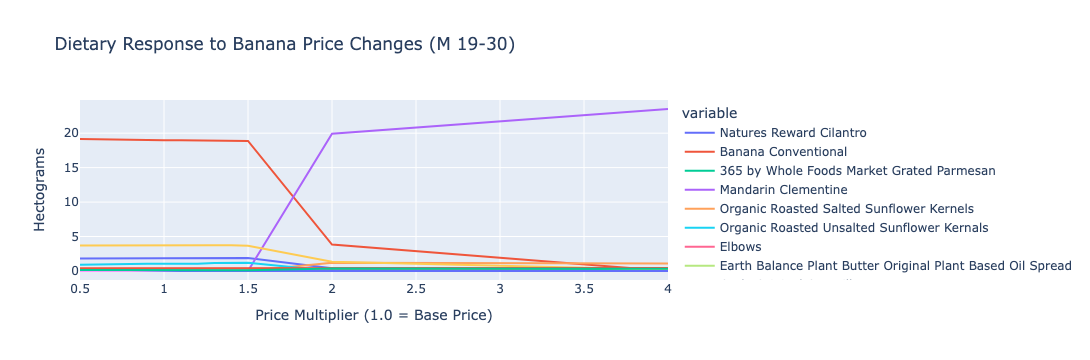

In [24]:
ReferenceGoods = ['Banana Conventional', 'Organic Banana']

scale = [0.5,0.75,0.9,1.,1.1,1.2,1.3,1.4,1.5,2,4]

cost0 = solve_subsistence_problem(FoodNutrients,Prices,diet_min[group],diet_max[group],tol=tol).fun

diet_results = {}

for s in scale:
    my_p = Prices.copy()
    for item in ReferenceGoods:
        my_p[item] = Prices[item] * s
    
    result = solve_subsistence_problem(FoodNutrients,my_p,diet_min[group],diet_max[group],tol=tol)
    diet_results[s] = result.diet

Diet_response = pd.DataFrame(diet_results).T
Diet_response.index.name = 'Banana Price Multiplier'
Diet_response.index = [float(getattr(s, 'magnitude', s)) for s in Diet_response.index]

is_consumed = (Diet_response>tol).sum()>0
filtered_diet = Diet_response.loc[:, is_consumed]
filtered_diet.plot(labels=dict(index='Price Multiplier (1.0 = Base Price)', value='Hectograms'),
    title=f"Dietary Response to Banana Price Changes ({group})")

From the plot, we could notice that once the price multiplier of Bananas reaches **2**, the solution would features large amount of **Mandarin** instead of Bananas. This makes sense as Mandarins are one of the cheaper items in Whole Foods.

In the next case, we would look at how price changes to all Fresh Produce items would have an impact on Subsistence Diet Cost, as both Bananas and Mandarins are part of the Fresh Produce categories.

#### Case 3: Price Change in **Fresh Produce Foods** on Subsistence Diet
Beyond looking at the price change in Bananas, we now look at how the price of **Fresh Produce Foods** changes on the subsistence diet cost.

**Code could take about a minute to compute. Code is adopted from lecture notebooks.**

In [25]:
# Recap: df has a column "Brand" which stores the brand the food belongs to.
target_brand = 'Fresh Produce'
brand_items = df[df['Brand'] == target_brand].index.tolist()
brand_items = [item for item in brand_items if item in Prices.index]

# Scale is different, here specifically curated for differences
scale = [0.25, 0.5, 1.0, 1.5, 2, 2.5, 3, 4, 4.5, 5, 5.5]
brand_diet_results = {}

for s in scale:
    my_p = Prices.copy()
    
    # Scale every item belonging to this brand
    for item in brand_items:
        my_p[item] = Prices[item] * s
    
    result = solve_subsistence_problem(FoodNutrients, my_p, diet_min[group], diet_max[group], tol=tol)
    brand_diet_results[s] = result.diet

Brand_Response = pd.DataFrame(brand_diet_results).T
Brand_Response.index = [float(getattr(x, 'magnitude', x)) for x in Brand_Response.index]
is_consumed = (Brand_Response > tol).any()
filtered_brand_diet = Brand_Response.loc[:, is_consumed]
filtered_brand_diet.plot(
    title=f"Dietary Response to {target_brand} Price Changes ({group})",
    labels=dict(index='Price Multiplier', value='Hectograms')
)

This is quite interesting, as when you look at price changes of all fresh produce items, this has a great impact on the diet cost. Once the price multiplier increases to 2, you could notice the decreasing demand for those items (Bananas) and increasing demand for other substitutes.

## Total Cost of Population, <span style="color: red;">*Deliverable [B] What is the Total Cost for Population of Interest* <a name="population-f"></span></a>

In this section, we calculate the aggregate cost of maintaining a vegan diet for the entire UC Berkeley undergraduate vegan population. This is achieved by extrapolating our polling data and the official university enrollment statistics.
* **Vegan Prevalence ($P_{v}$):** The percentage of students identifying as vegan based on our primary data collection.
* **Total Population ($N$):** According to the [UC Berkeley Quick Facts](https://opa.berkeley.edu/campus-data/uc-berkeley-quick-facts), the undergraduate population is approximately **33,122**.
* **Average Dietary Cost ($\bar{C}$):** The mean of the minimum cost diet ranges calculated for the relevant age demographics.

### Calculations
To find the **Total Cost** ($T$), we apply the following formula:

$$T = N \times P_{v} \times \bar{C}$$

**Variable Definitions:**
* $T$: Total aggregate cost for the UC Berkeley vegan undergraduate population.
* $N$: Total number of undergraduate students ($N = 33,122$).
* $P_{v}$: Percentage of vegan students (expressed as a decimal).
* $\bar{C}$: Average price of the minimum cost diet across selected age ranges.

---

| Variable | Description | Source |
| :--- | :--- | :--- |
| $N$ | Total Undergraduates | UC Berkeley OPA |
| $P_{v}$ | Vegan Student Ratio | Primary Polling Data |
| $\bar{C}$ | Mean Diet Cost | Average of Calculated Ranges |

> **Note:** For simplicity, we utilize the average of the solution prices for the ranges calculated to provide a representative figure for the diverse age brackets within the undergraduate community.

In [43]:
percent = 0.08
avg_cost = float(np.average(cost_df))
N = 33122

Total = N * percent * avg_cost
print(f"The total cost of maintaining a vegan diet for the UC Berkeley vegan undergraduate population is ${Total}.")

The total cost of maintaining a vegan diet for the UC Berkeley vegan undergraduate population is $28085.99448175557.
